Mini Project wet assignment

by Ofri Leifer & Tavor Ashkenazi

# Encoder Comparison Analysis
This notebook evaluates the performance of six trained encoders on downstream classification tasks.
We compare the training, validation, and test accuracy for each encoder. For the two self-supervised
autoencoders, we also report the mean reconstruction error (mean absolute error).


### Imports


In [1]:
import sys
# print(sys.executable)
%matplotlib inline
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the trained encoders and classifiers
from torchvision.models import resnet18
from models import ConvAutoencoder, ConvAutoencoderMNIST, EncoderClassifierCIFAR, EncoderClassifierMNIST, Classifier, SimCLR
from train import train_simclr,train_classifier_with_encoder, train_autoencoder,train_classifier_with_frozen_encoder, train_encoder_classifier
from evaluate import evaluate_simclr,evaluate_classifier_on_validation,evaluate_simclr_on_validation,evaluate_classifier_self
from dataloader import load_data_classification,load_data_simclr, load_data,load_data_self_supervised
import argparse
from utils import plot_tsne_Title

def get_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('--seed', default=0, type=int, help='Seed for random number generators')
    parser.add_argument('--data-path', default="/datasets/cv_datasets/data", type=str, help='Path to dataset')
    parser.add_argument('--batch-size', default=8, type=int, help='Size of each batch')
    parser.add_argument('--latent-dim', default=128, type=int, help='Encoding dimension')
    parser.add_argument('--device', default='cuda' if torch.cuda.is_available() else 'cpu', type=str, help='Default device to use')
    parser.add_argument('--mnist', action='store_true', default=False, help='Whether to use MNIST (True) or CIFAR10 (False) data')
    parser.add_argument('--self-supervised', action='store_true', default=False, help='Train self-supervised with reconstruction objective')
    parser.add_argument('--simclr', action='store_true', default=False, help='Whether to use SimCLR augmentations')
    return parser.parse_args()
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load datasets
# sys.argv = [
#     'notebook',  # Simulate the script name
#     '--data-path', './data',
#     '--batch-size', '128',
#     '--latent-dim', '128',
#     '--device', 'cuda',
#     '--simclr'  # Add any other flags you want to enable
# ]
# args = get_args()

### **Classifier Architecture Explanation**

The classifier was designed to complement the encoder and is tailored to handle the **CIFAR-10 dataset**, which is relatively harder to train compared to MNIST due to its higher complexity and RGB images.
At first we used 512(layer1) -> 256(layer2) -> 128(layer 3) [self-supervised cifar] which did not hold enough information(low accuracy after training) which is why we decided to increase the neurons in each layer to increase the amount of features it would be able to hold hoping that it increases the accuracy and it did. As we have seen during the semester, bigger layers require bigger dropout rates to mitigate overfitting. After witnessing a plataeu of validation set in training of cifar10 we have come to the conclusion that the classifier need to hold more neurons. The classifier would then be able to hold more features. The large network would require large dropout to avoid overfitting. In the end we chose 1024 neurons each layer and 0.9 dropout to match the size of the layer(each time we increased the size by *2, we added dropout +0.1 and reduced the learning rate in training)

Below are the key design choices:

#### **1. Compact 3-Layer Design**
- The classifier consists of **3 fully connected layers**:
  - **Layer 1**: Maps the latent dimension to 1024 neurons.
  - **Layer 2**: keeps dimensionality at 1024 neurons.
  - **Layer 3**: Outputs predictions for the number of classes (e.g., 10 for CIFAR-10).
- This compact design ensures faster training while maintaining sufficient capacity to learn complex patterns from CIFAR-10.


#### **2. Dropout for Regularization**

when training for self-supervised Cifar we got major overfitting which we chose to combat with dropout. increasing it steadily until we reached a point we're happy with. we used higher dropout rate for bigger layers:
- **High Dropout (0.9) Between Layers**:
  - The layers have 1024 neurons, which has high the risk of overfitting.
  - A high dropout rate of **0.9** ensures that the model does not rely too heavily on specific neurons, encouraging it to learn more robust features.

#### **3. Tailored for CIFAR-10**
- The architecture is designed to handle the complexity of CIFAR-10, which has more diverse and detailed features compared to MNIST.
- The 3-layer design ensures that the classifier can effectively map the latent features from the encoder to the output classes.

#### **4. Flexibility for MNIST**
- While the classifier is tailored for CIFAR-10, it is also compatible with MNIST due to its compact design and regularization, which prevents overfitting on simpler datasets.


## **Learning rates**

When deciding which learning rate to use for each task our go-to options were:

-       Adam/W: optimizer 'role', which is known to be good for general flexible tasks w. l.r. 1e-3 
        (+weight decay 1e-4 if overfitting[validation % < classification %])

-       CosineLR: scheduler 'role' w. l.r. 1e-3

-       SGD: optimizer 'role' w. l.r. 0.08

-       ReduceLrOnPlat.: scheduler 'role' w. l.r. 1e-3 


# 1.2.1 Self-Supervised Autoencoding

### **Findings on Data Augmentation and Batch Sizes**

#### **1. Data Augmentation During Pre-Training**
- During experimentation, we observed that **not augmenting the data during pre-training** led to better results for both:
  - **Classification Accuracy**: The classifier achieved higher accuracy when the encoder was pre-trained on unaugmented data.
  - **Reconstruction Loss**: The autoencoder produced more accurate reconstructions when trained on unaugmented data.
- **Reason**:
  - Data augmentation introduces variability in the input data, which can make it harder for the encoder to learn a stable and meaningful latent representation.
  - For self-supervised tasks like autoencoding, the goal is to reconstruct the input as accurately as possible. Augmented data (e.g., cropped, rotated, or jittered images) can make this task unnecessarily difficult, leading to suboptimal latent representations.

#### **2. Small Batch Sizes for Self-Supervised Training**
- Research online suggested that using **small batch sizes** during self-supervised training improves both classification accuracy and reconstruction loss, which is why we chose batch size = 64(not too high-128 and not too low - 32).
- **Reason**:
  - Small batch sizes introduce more noise into the gradient updates, which acts as a form of implicit regularization. This helps the model learn more robust and generalizable features.
  - For self-supervised tasks, small batch sizes encourage the encoder to focus on learning meaningful representations rather than overfitting to specific patterns in the data.

#### **Key Takeaways**
- **No Data Augmentation**:
  - Avoiding data augmentation during pre-training ensures that the encoder learns stable latent representations, which improves downstream classification and reconstruction performance.
- **Small Batch Sizes**:
  - Using small batch sizes during self-supervised training helps the model generalize better by introducing noise into the optimization process.


### **CIFAR training: Self-Supervised**

## **Encoder Architecture**

When training the encoder we noticed the classifier training validation set plataued at 55%, even changing the classifier/encoder(with latent dim = 128 as requirement) and did not help the validation accuracy increase. This led us to beleive the latent space was not forming correctly. 

**Kernel Size = 6**
We use kernel size 6 to be able to capture more features in the next part(1.2.2) and use the same encoder. We have noticed that increasing kernel size to 6 slightly improves the accuracy of the classifier as it helps capturing more features. however, as the latent dimension is 128 improving the results would require more computational time and would not imrpove it by much.

**neurons in each layer**
We found out that increasing the neurons in each layer highly increases computation time, and did not yield for a much better latent space(which would help the accuracy of the validation set). This is why we decided to keep a small and simple implemenation:

### **Encoder**
```python
self.encoder = nn.Sequential(
    nn.Conv2d(3, 128, kernel_size=6, stride=2, padding=2),  # Input: 32x32x3 -> Output: 8x8x128
    nn.ReLU(),
    nn.Conv2d(128, 256, kernel_size=6, stride=2, padding=2),  # Input: 8x8x128 -> Output: 8x8x256
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(8 * 8 * 256, latent_dim),  # Input: 8x8x256
    nn.ReLU()
)

```
We used 3 in channels to match the RGB images in Cifar.


### **Encoder Training: Self-Supervised**
### **Loss Function, Optimizer, and Scheduler Choices**

#### **1. Loss Function**
- We tested several loss functions for training the autoencoder, including:
  - **L1 Loss**: Measures the mean absolute error between the reconstructed and original images.
  - **L2 Loss (MSE)**: Measures the mean squared error.
  - **Smooth L1 Loss**: A combination of L1 and L2 losses.
- **Findings**:
  - **L1 Loss** performed almost equally well compared to its competitors in terms of reconstruction quality.
  - We chose **L1 Loss** because it is less sensitive to outliers compared to L2 Loss, making it more robust for reconstruction tasks.

#### **2. Optimizer**
- We experimented with several optimizers, including:
  - **Adam**: Adaptive learning rate optimization.
  - **RMSProp**: Root Mean Square Propagation.
  - **SGD**: Stochastic Gradient Descent.
- **Findings**:
  - **SGD** was chosen because it provided both fast convergence and good reconstruction loss.
  - With **SGD**, we achieved a reasonable loss comparable to or better than the results obtained with Adam and RMSProp.

#### **3. Momentum**
- **Momentum (0.9)**:
  - Momentum helps accelerate convergence by dampening oscillations in the optimization process.
  - A momentum value of **0.9** was chosen as it is a commonly used value that balances stability and speed.

#### **4. Learning Rate Scheduler**
- We used **CosineAnnealingLR** as the learning rate scheduler.
- **Why CosineAnnealingLR?**
  - Cosine annealing gradually reduces the learning rate, allowing the model to converge smoothly.
  - While **ReduceLROnPlateau** is more commonly used for encoder training, we found that **CosineAnnealingLR** worked equally well for this task.
  - Since SGD already provided good reconstruction loss, the choice of scheduler (CosineAnnealingLR or ReduceLROnPlateau) did not make a significant difference.

#### **Key Takeaways**
- **L1 Loss** was chosen for its robustness and comparable performance to other loss functions.
- **SGD** with momentum and weight decay provided fast convergence and good reconstruction loss.
- **CosineAnnealingLR** was used as the scheduler, but the choice of scheduler did not significantly impact the results due to the effectiveness of SGD.

### **Classifier training: Self-Supervised**
### **Classifier Training: Loss Function, Optimizer, and Scheduler Choices**

#### **1. Loss Function**
- We used **CrossEntropyLoss** as the classification loss function.
- **Why CrossEntropyLoss?**
  - It is the standard loss function for multi-class classification tasks.
  - It measures the difference between the predicted class probabilities and the true class labels, making it well-suited for training the classifier.

#### **2. Optimizer**
- We chose **Adam** as the optimizer for training the classifier.
- **Why Adam?**
  - Adam is a widely used optimizer that combines the benefits of **momentum** and **adaptive learning rates**.
  - It is highly flexible and performs well across a variety of tasks, including classification.
  - Adam requires minimal hyperparameter tuning, making it a reliable choice for this task.

#### **3. Learning Rate Scheduler**
- We used **CosineAnnealingLR** as the learning rate scheduler.
- **Why CosineAnnealingLR?**
  - Cosine annealing is commonly used for classifier training as it gradually reduces the learning rate in a smooth, cyclic manner.
  - This helps the model converge more effectively by allowing it to explore the loss landscape early in training and fine-tune the weights later.
  - CosineAnnealingLR is particularly effective when combined with Adam, as it complements Adam's adaptive learning rate mechanism.

## **Number of epochs**

Although increasing the number of epochs helped the model, It only did so slightly(increased to 55%+-1). which is why we decided that 10 epochs would suffice.

In [2]:
# Define paths
base_folder = 'saved_models'
self_supervised_folder = os.path.join(base_folder, 'self_supervised_cifar10')  # Adjust for dataset (e.g., cifar10, mnist)

# Create the folder if it doesn't exist
os.makedirs(self_supervised_folder, exist_ok=True)

# Define paths for autoencoder and classifier
autoencoder_path = os.path.join(self_supervised_folder, 'autoencoder.pth')
classifier_path = os.path.join(self_supervised_folder, 'classifier.pth')

# Simulate command-line arguments
sys.argv = [
    'notebook',  # Placeholder for the script name
    '--batch-size', '64',
    '--device', device.type,
    '--self-supervised',  # Enable self-supervised flag
    '--latent-dim', '128'
]

args = get_args()

# Load data
train_loader, val_loader, test_loader, input_dim,train_encoder_dataset = load_data_self_supervised(args)
test_loader_self_supervised_cifar = test_loader
# Initialize and train the model based on the self-supervised flag
device = torch.device(args.device)
if args.self_supervised:
    # Initialize the autoencoder
    if args.mnist:
        autoencoder_self_supervised_mnist = ConvAutoencoderMNIST(latent_dim=args.latent_dim).to(device)
    else:
        autoencoder_self_supervised_cifar = ConvAutoencoder(latent_dim=args.latent_dim).to(device)
    
    # Initialize the classifier
    classifier = Classifier(latent_dim=args.latent_dim, num_classes=10).to(device)

    # Check if the autoencoder and classifier weights exist
    if os.path.exists(autoencoder_path) and os.path.exists(classifier_path):
        print("Loading pre-trained autoencoder and classifier...")
        autoencoder_self_supervised_cifar.load_state_dict(torch.load(autoencoder_path))
        classifier.load_state_dict(torch.load(classifier_path))
    else:
        print("Autoencoder weights not found. Training autoencoder...")
        
        # Step 1: Train the autoencoder
        train_autoencoder(autoencoder_self_supervised_cifar, train_encoder_dataset, val_loader, device, num_epochs=10, learning_rate=0.5)
        
        # Save the trained autoencoder weights
        torch.save(autoencoder_self_supervised_cifar.state_dict(), autoencoder_path)
        print(f"Autoencoder weights saved to {autoencoder_path}")

        # Step 2: Train the classifier with the frozen encoder
        print("Training Classifier with Frozen Encoder...")
        train_classifier_with_frozen_encoder(autoencoder_self_supervised_cifar, classifier, train_loader, val_loader, device, num_epochs=10, learning_rate=3e-4)
        
        # Save the trained classifier weights
        torch.save(classifier.state_dict(), classifier_path)
        print(f"Classifier weights saved to {classifier_path}")

    # Evaluate the classifier
    evaluate_classifier_self(classifier, autoencoder_self_supervised_cifar.encoder, test_loader, device)

    # Plot t-SNE visualizations (optional)
    # plot_tsne(autoencoder.encoder, test_loader, device)

Autoencoder weights not found. Training autoencoder...
Epoch [1/10], Reconstruction Loss: 0.1090
Epoch [2/10], Reconstruction Loss: 0.0845
Epoch [3/10], Reconstruction Loss: 0.0799
Epoch [4/10], Reconstruction Loss: 0.0771
Epoch [5/10], Reconstruction Loss: 0.0741
Epoch [6/10], Reconstruction Loss: 0.0726
Epoch [7/10], Reconstruction Loss: 0.0700
Epoch [8/10], Reconstruction Loss: 0.0674
Epoch [9/10], Reconstruction Loss: 0.0655
Epoch [10/10], Reconstruction Loss: 0.0641
Mean Reconstruction Error (Training Set): 0.0627
Autoencoder weights saved to saved_models\self_supervised_cifar10\autoencoder.pth
Training Classifier with Frozen Encoder...
Epoch [1/10], Classification Loss: 2.2256, Accuracy: 16.13%
Validation - Classification Loss: 2.0392, Accuracy: 29.12%
Epoch [2/10], Classification Loss: 1.8191, Accuracy: 35.63%
Validation - Classification Loss: 1.7273, Accuracy: 38.70%
Epoch [3/10], Classification Loss: 1.6404, Accuracy: 41.71%
Validation - Classification Loss: 1.6091, Accuracy: 

### **MNIST Autoencoder Architecture**

### **Encoder**
```python
encoder = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),  # 28x28x1 -> 14x14x64
    nn.ReLU(),
    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 14x14x64 -> 7x7x128
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(7*7*128, latent_dim),  # Adjusted for 7x7x128 output
    nn.ReLU()
)
```
1 input channel for the greyscale input.
kernel size 4 was enough to capture the latent space of the simpler dataset and was faster to compute than the one we used for Cifar.

the training proccess used for Cifar seemed to work well for Mnist which is why we kept it as it was.

In [3]:
# Define paths
base_folder = 'saved_models'
self_supervised_folder = os.path.join(base_folder, 'self_supervised_mnist')  # Adjust for dataset (e.g., cifar10, mnist)

# Create the folder if it doesn't exist
os.makedirs(self_supervised_folder, exist_ok=True)

# Define paths for autoencoder and classifier
autoencoder_path = os.path.join(self_supervised_folder, 'autoencoder.pth')
classifier_path = os.path.join(self_supervised_folder, 'classifier.pth')

# Simulate command-line arguments
sys.argv = [
    'notebook',  # Placeholder for the script name
    '--batch-size', '64',
    '--device', device.type,
    '--self-supervised',  # Enable self-supervised flag
    '--mnist',
    '--latent-dim', '128'
]

args = get_args()

# Load data
train_loader, val_loader, test_loader, input_dim,train_encoder_loader = load_data_self_supervised(args)
test_loader_self_supervised_mnist = test_loader
# Initialize and train the model based on the self-supervised flag
device = torch.device(args.device)
if args.self_supervised:
    # Initialize the autoencoder
    if args.mnist:
        autoencoder_self_supervised_mnist = ConvAutoencoderMNIST(latent_dim=args.latent_dim).to(device)
    else:
        autoencoder_self_supervised_cifar = ConvAutoencoder(latent_dim=args.latent_dim).to(device)
    
    # Initialize the classifier
    classifier = Classifier(latent_dim=args.latent_dim, num_classes=10).to(device)

    # Check if the autoencoder and classifier weights exist
    if os.path.exists(autoencoder_path) and os.path.exists(classifier_path):
        print("Loading pre-trained autoencoder and classifier...")
        autoencoder_self_supervised_mnist.load_state_dict(torch.load(autoencoder_path))
        classifier.load_state_dict(torch.load(classifier_path))
    else:
        print("Autoencoder weights not found. Training autoencoder...")
        
        # Step 1: Train the autoencoder
        train_autoencoder(autoencoder_self_supervised_mnist, train_encoder_loader, val_loader, device, num_epochs=10, learning_rate=0.5)
        
        # Save the trained autoencoder weights
        torch.save(autoencoder_self_supervised_mnist.state_dict(), autoencoder_path)
        print(f"Autoencoder weights saved to {autoencoder_path}")

        # Step 2: Train the classifier with the frozen encoder
        print("Training Classifier with Frozen Encoder...")
        train_classifier_with_frozen_encoder(autoencoder_self_supervised_mnist, classifier, train_loader, val_loader, device, num_epochs=10, learning_rate=3e-4)
        
        # Save the trained classifier weights
        torch.save(classifier.state_dict(), classifier_path)
        print(f"Classifier weights saved to {classifier_path}")

    # Evaluate the classifier
    evaluate_classifier_self(classifier, autoencoder_self_supervised_mnist.encoder, test_loader, device)

    # Plot t-SNE visualizations (optional)
    # plot_tsne(autoencoder.encoder, test_loader, device)

Autoencoder weights not found. Training autoencoder...
Epoch [1/10], Reconstruction Loss: 0.0463
Epoch [2/10], Reconstruction Loss: 0.0255
Epoch [3/10], Reconstruction Loss: 0.0239
Epoch [4/10], Reconstruction Loss: 0.0228
Epoch [5/10], Reconstruction Loss: 0.0217
Epoch [6/10], Reconstruction Loss: 0.0205
Epoch [7/10], Reconstruction Loss: 0.0191
Epoch [8/10], Reconstruction Loss: 0.0178
Epoch [9/10], Reconstruction Loss: 0.0165
Epoch [10/10], Reconstruction Loss: 0.0155
Mean Reconstruction Error (Training Set): 0.0155
Autoencoder weights saved to saved_models\self_supervised_mnist\autoencoder.pth
Training Classifier with Frozen Encoder...
Epoch [1/10], Classification Loss: 1.5135, Accuracy: 48.20%
Validation - Classification Loss: 0.6104, Accuracy: 83.78%
Epoch [2/10], Classification Loss: 0.3929, Accuracy: 88.95%
Validation - Classification Loss: 0.3323, Accuracy: 90.08%
Epoch [3/10], Classification Loss: 0.2780, Accuracy: 91.87%
Validation - Classification Loss: 0.2572, Accuracy: 92

# 1.2.2 Classification-Guided Encoding

In order to be able to compare accuracy over the Classification training we decided to keep the encoder implementation the same as in 1.2.1.along with the batch size. However, we did add classification training to the encoder training proccess so that the classifier and encoder could converge together, improving the classifier accuracy.

## **Classification guided Cifar training**

In [4]:
# Define paths
base_folder = 'saved_models'
autoencoder_folder = os.path.join(base_folder, 'autoencoder_cifar10')  # Adjust for dataset (e.g., cifar10, mnist)

# Create the folder if it doesn't exist
os.makedirs(autoencoder_folder, exist_ok=True)

# Define paths for autoencoder and classifier
autoencoder_path = os.path.join(autoencoder_folder, 'autoencoder.pth')
classifier_path = os.path.join(autoencoder_folder, 'classifier.pth')

# Simulate command-line arguments
sys.argv = [
    'notebook',  # Placeholder for the script name
    '--batch-size', '64',
    '--device', device.type,
    '--latent-dim', '128'
]

args = get_args()

# Load data
train_loader, val_loader, test_loader, input_dim = load_data(args)
test_loader_classification_cifar = test_loader
# Initialize and train the model for non-self-supervised autoencoder
device = torch.device(args.device)

if not args.self_supervised:
    # Initialize the autoencoder
    if args.mnist:
        autoencoder_classification_mnist = ConvAutoencoderMNIST(latent_dim=args.latent_dim).to(device)
    else:
        autoencoder_classification_cifar = ConvAutoencoder(latent_dim=args.latent_dim).to(device)
    
    # Initialize the classifier
    classifier = Classifier(latent_dim=args.latent_dim, num_classes=10).to(device)

    # Check if the autoencoder and classifier weights exist
    if os.path.exists(autoencoder_path) and os.path.exists(classifier_path):
        print("Loading pre-trained autoencoder and classifier...")
        autoencoder_classification_cifar.load_state_dict(torch.load(autoencoder_path))
        classifier.load_state_dict(torch.load(classifier_path))
    else:
        print("Autoencoder weights not found. Training autoencoder and classifier jointly...")
        
        # Train the autoencoder and classifier jointly
        train_encoder_classifier(encoder=autoencoder_classification_cifar, classifier=classifier, train_loader=train_loader, val_loader=val_loader, device=device, num_epochs=10, learning_rate=2e-4)
        
        # Save the trained autoencoder and classifier weights
        torch.save(autoencoder_classification_cifar.state_dict(), autoencoder_path)
        torch.save(classifier.state_dict(), classifier_path)
        print(f"Autoencoder weights saved to {autoencoder_path}")
        print(f"Classifier weights saved to {classifier_path}")

    
    # Evaluate the classifier
    evaluate_classifier_self(classifier, autoencoder_classification_cifar.encoder, test_loader, device)

    # Plot t-SNE visualizations (optional)
    # plot_tsne(autoencoder.encoder, test_loader, device)

Autoencoder weights not found. Training autoencoder and classifier jointly...
Epoch [1/10], Loss: 2.1458, Accuracy: 16.11%
Validation Loss: 1.8380, Accuracy: 25.32%
Epoch [2/10], Loss: 1.4608, Accuracy: 45.49%
Validation Loss: 1.2614, Accuracy: 53.80%
Epoch [3/10], Loss: 1.1567, Accuracy: 58.16%
Validation Loss: 1.1401, Accuracy: 59.44%
Epoch [4/10], Loss: 0.9873, Accuracy: 64.69%
Validation Loss: 1.0282, Accuracy: 64.66%
Epoch [5/10], Loss: 0.8635, Accuracy: 69.44%
Validation Loss: 1.0340, Accuracy: 64.10%
Epoch [6/10], Loss: 0.7611, Accuracy: 73.17%
Validation Loss: 0.9643, Accuracy: 66.08%
Epoch [7/10], Loss: 0.6722, Accuracy: 76.58%
Validation Loss: 0.9545, Accuracy: 67.14%
Epoch [8/10], Loss: 0.6043, Accuracy: 79.21%
Validation Loss: 0.9476, Accuracy: 67.80%
Epoch [9/10], Loss: 0.5533, Accuracy: 81.31%
Validation Loss: 0.9543, Accuracy: 68.00%
Epoch [10/10], Loss: 0.5253, Accuracy: 82.42%
Validation Loss: 0.9568, Accuracy: 68.20%
Autoencoder weights saved to saved_models\autoencod

## **Classification guided Mnist training**

We kept the same implementation for Mnist from 1.2.1..

As we did in Cifar training in 1.2.2 we added the classifier training to the encoder training.

In [5]:
# Define paths
base_folder = 'saved_models'
autoencoder_folder = os.path.join(base_folder, 'autoencoder_mnist')  # Adjust for dataset (e.g., cifar10, mnist)

# Create the folder if it doesn't exist
os.makedirs(autoencoder_folder, exist_ok=True)

# Define paths for autoencoder and classifier
autoencoder_path = os.path.join(autoencoder_folder, 'autoencoder.pth')
classifier_path = os.path.join(autoencoder_folder, 'classifier.pth')

# Simulate command-line arguments
sys.argv = [
    'notebook',  # Placeholder for the script name
    '--batch-size', '64',
    '--device', device.type,
    '--latent-dim', '128',
    '--mnist'
]

args = get_args()

# Load data
train_loader, val_loader, test_loader, input_dim = load_data(args)
test_loader_classification_mnist = test_loader
# Initialize and train the model for non-self-supervised autoencoder
device = torch.device(args.device)

if not args.self_supervised:
    # Initialize the autoencoder
    if args.mnist:
        autoencoder_classification_mnist = ConvAutoencoderMNIST(latent_dim=args.latent_dim).to(device)
    else:
        autoencoder_classification_cifar = ConvAutoencoder(latent_dim=args.latent_dim).to(device)
    
    # Initialize the classifier
    classifier = Classifier(latent_dim=args.latent_dim, num_classes=10).to(device)

    # Check if the autoencoder and classifier weights exist
    if os.path.exists(autoencoder_path) and os.path.exists(classifier_path):
        print("Loading pre-trained autoencoder and classifier...")
        autoencoder_classification_mnist.load_state_dict(torch.load(autoencoder_path))
        classifier.load_state_dict(torch.load(classifier_path))
    else:
        print("Autoencoder weights not found. Training autoencoder and classifier jointly...")
        
        # Train the autoencoder and classifier jointly
        train_encoder_classifier(encoder=autoencoder_classification_mnist, classifier=classifier, train_loader=train_loader, val_loader=val_loader, device=device, num_epochs=10, learning_rate=1e-3)
        
        # Save the trained autoencoder and classifier weights
        torch.save(autoencoder_classification_mnist.state_dict(), autoencoder_path)
        torch.save(classifier.state_dict(), classifier_path)
        print(f"Autoencoder weights saved to {autoencoder_path}")
        print(f"Classifier weights saved to {classifier_path}")

    test_loader_classification_mnist = test_loader
    # Evaluate the classifier
    evaluate_classifier_self(classifier, autoencoder_classification_mnist.encoder, test_loader, device)

    # Plot t-SNE visualizations (optional)
    # plot_tsne(autoencoder.encoder, test_loader, device)

Autoencoder weights not found. Training autoencoder and classifier jointly...
Epoch [1/10], Loss: 0.5060, Accuracy: 83.21%
Validation Loss: 0.1053, Accuracy: 97.25%
Epoch [2/10], Loss: 0.0643, Accuracy: 98.21%
Validation Loss: 0.0673, Accuracy: 98.20%
Epoch [3/10], Loss: 0.0409, Accuracy: 98.77%
Validation Loss: 0.0592, Accuracy: 98.23%
Epoch [4/10], Loss: 0.0289, Accuracy: 99.11%
Validation Loss: 0.0648, Accuracy: 98.23%
Epoch [5/10], Loss: 0.0201, Accuracy: 99.38%
Validation Loss: 0.0639, Accuracy: 98.62%
Epoch [6/10], Loss: 0.0123, Accuracy: 99.62%
Validation Loss: 0.0633, Accuracy: 98.67%
Epoch [7/10], Loss: 0.0066, Accuracy: 99.82%
Validation Loss: 0.0611, Accuracy: 98.90%
Epoch [8/10], Loss: 0.0028, Accuracy: 99.92%
Validation Loss: 0.0678, Accuracy: 98.85%
Epoch [9/10], Loss: 0.0013, Accuracy: 99.97%
Validation Loss: 0.0662, Accuracy: 98.88%
Epoch [10/10], Loss: 0.0007, Accuracy: 99.98%
Validation Loss: 0.0676, Accuracy: 98.92%
Autoencoder weights saved to saved_models\autoencod

# **1.2.3 Structured Latent Spaces**

SimCLR Architecture Explanation
The SimCLR architecture is designed for self-supervised learning, where the model learns meaningful representations of data without requiring labeled examples. Below is a detailed explanation of the structure and design choices:

1. Encoder
The encoder is the backbone of the SimCLR model, responsible for extracting high-level features from the input images.
In this implementation, the encoder is a base_encoder (We chose ResNet-18 for speed and simplicity), which outputs a feature vector of size 512 after the global average pooling (GAP) layer.
Why this choice?
ResNet is a well-established architecture for feature extraction, known for its ability to capture hierarchical features from images.
The encoder outputs a fixed-size feature vector (512 dimensions), which is suitable for downstream tasks.
2. Projection Head
The projection head is a small neural network that maps the encoder's feature vector to a lower-dimensional space where contrastive learning is performed.

In this implementation:

The projection head consists of:
A linear layer: Maps the 512-dimensional feature vector to the projection_dim (h_dim = 128, as in 1.2.1./1.2.2.).
A batch normalization layer: Ensures stable training by normalizing the outputs.
A ReLU activation: Introduces non-linearity to the projection head.
The output of the projection head is normalized to lie on the unit hypersphere using F.normalize.
Why this choice?

The projection head decouples the encoder's feature space from the contrastive learning space, allowing the encoder to learn general-purpose features.
The lower-dimensional space (e.g., 128 dimensions) reduces computational complexity and focuses the model on learning compact representations.
3. Latent Projection
The latent_projection layer is an additional linear layer that maps the encoder's feature vector (512 dimensions) to a fixed latent space (128 dimensions).

Why this choice?

The latent projection provides a consistent representation size (128 dimensions) for downstream tasks, making it easier to integrate with classifiers or other models.

4. Forward Pass
The forward pass has two modes:
- Latent Mode (return_latent=True):
The encoder's feature vector is passed through the latent_projection layer to produce a 128-dimensional latent representation.
This mode is useful for downstream tasks like classification or clustering.
- Projection Mode (return_latent=False):
The encoder's feature vector is passed through the projection_head and normalized to lie on the unit hypersphere.
This mode is used during contrastive learning to compute the contrastive loss.

# Motivation and Literature
The SimCLR architecture is inspired by the paper "A Simple Framework for Contrastive Learning of Visual Representations" by Chen et al. (2020). The key motivation behind the design is to learn representations by maximizing agreement between augmented views of the same image in the latent space, while minimizing agreement with views of other images.

Key Insights from the Paper:
The projection head improves the quality of the learned representations by decoupling the encoder's feature space from the contrastive learning space.
Normalization on the unit hypersphere ensures that the contrastive loss focuses on angular relationships, improving feature separation.

# Hyperparameter and Data Tuning Considerations

1. **Data Augmentations**

    Data augmentations are critical in SimCLR as they create diverse views of the same image, forcing the model to learn invariant representations. For pretraining, we used strong augmentations to maximize the diversity of positive pairs, while for classification, we used milder augmentations to better align with the downstream task.

    Pretraining Augmentations:

    The following augmentations were applied during pretraining:
    ```python
    data_transforms = transforms.Compose([
        transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),  # Random crops
        transforms.RandomHorizontalFlip(),  # Horizontal flips
        transforms.RandomApply([transforms.ColorJitter(0.8, 0.8, 0.8, 0.2)], p=0.8),  # Color jitter
        transforms.RandomGrayscale(p=0.2),  # Random grayscale
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=5)], p=0.5),  # Gaussian blur
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])  # CIFAR-10 normalization
    ])
    ```
    **Why these augmentations?**
    
    RandomResizedCrop and RandomHorizontalFlip introduce spatial variability.
    ColorJitter and RandomGrayscale simulate changes in lighting and color.
    GaussianBlur simulates out-of-focus images, improving robustness.
    These augmentations ensure that the model learns to focus on semantic content rather than low-level details.
    Classification Augmentations:

    For classification, we used milder augmentations to avoid distorting the data too much:
    ```python
    classification_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])  # CIFAR-10 normalization
    ])
    ```
    **Why milder augmentations?**

    During classification, the goal is to fine-tune the model on clean data that resembles the test set. Strong augmentations could harm performance by introducing unnecessary noise.

2. **Temperature Parameter (τ)**

    The temperature parameter in the contrastive loss controls the sharpness of the similarity distribution. A lower temperature sharpens the distribution, making the model more sensitive to differences between positive and negative pairs.

    Choice of Temperature:
    Based on the findings in the SimCLR paper, we set the temperature to 0.05, as it consistently yielded the best results.
    Why this choice?
    Lower temperatures improve feature separation in the latent space, leading to better representations.

3. **Batch Size**

    In blog "Contrastive Representation Learning" by Lilian Weng it states: "SimCLR needs a large batch size to incorporate enough negative samples to achieve good performance." experimenting with different batch sizes showed us that indeed that is true. We chose batch size 1024 which is relatively high.

4. **Learning rates**

    The learning rate was tuned using a cosine annealing scheduler to ensure smooth convergence.
    Initial learning rate: 1e-3 (scaled with batch size).
    Optimizer: Adam.
    Scheduler: CosineAnnealingLR.
    Why this choice?
    Adam is flexible and good optimizer for general perpose.
    Cosine annealing schedule ensures stable training as the model approaches convergence.

5. **Loss Function (NT-Xent)**

    Our nt-xent loss function implementation is inspired by the loss formula presented in "Contrastive Learning – SimCLR and BYOL (With Code Example)" by Shubham.
    The NT-Xent loss (Normalized Temperature-Scaled Cross-Entropy Loss) is a key component of the SimCLR framework. It is designed to maximize the similarity between positive pairs (augmented views of the same image) while minimizing the similarity between negative pairs (views of different images). 
    The NT-Xent loss with a temperature of 0.05 works effectively because:

    It sharpens the similarity distribution, improving feature separation.
    It encourages the model to focus on angular relationships, leading to invariant representations.
    Empirical evidence supports the use of lower temperatures for better contrastive learning.



# **training SimClr with NT-Xent over Cifar10:**

In [6]:
# Define paths
# Define base folder for saving models
base_folder = 'saved_models'
simclr_folder = os.path.join(base_folder, 'simclr_cifar10')  # Adjust for dataset (e.g., cifar10, mnist)

# Create the folder if it doesn't exist
os.makedirs(simclr_folder, exist_ok=True)

# Define paths for encoder and classifier
simclr_encoder_path = os.path.join(simclr_folder, 'encoder.pth')
simclr_classifier_path = os.path.join(simclr_folder, 'classifier.pth')

sys.argv = [
    'notebook',  # Placeholder for the script name
    '--batch-size', '1024',
    '--device', device.type,
    '--simclr'  # Add any other flags you want to enable
]

args = get_args()

# Load data for SimCLR pretraining
train_loader, val_loader, test_loader = load_data_simclr(args)

# Initialize SimCLR model
base_encoder = resnet18(pretrained=False)
if args.mnist:
    base_encoder.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
base_encoder.fc = torch.nn.Identity()  # Keep the encoder's output as (batch_size, 512)
simclr_model = SimCLR(base_encoder, projection_dim=128).to(device)

# Initialize classifier
classifier = Classifier(latent_dim=args.latent_dim, num_classes=10).to(device)

# Check if the SimCLR encoder and classifier weights exist
if os.path.exists(simclr_encoder_path) and os.path.exists(simclr_classifier_path):
    print("Loading pre-trained SimCLR encoder and classifier...")
    simclr_model.load_state_dict(torch.load(simclr_encoder_path))
    classifier.load_state_dict(torch.load(simclr_classifier_path))
else:
    print("SimCLR weights not found. Training SimCLR model...")
    
    # Train SimCLR model
    optimizer = torch.optim.Adam(simclr_model.parameters(), lr=1e-3)
    train_simclr(simclr_model, train_loader, val_loader, optimizer, device, num_epochs=10)
    
    # Save the trained encoder weights
    torch.save(simclr_model.state_dict(), simclr_encoder_path)
    print(f"SimCLR encoder weights saved to {simclr_encoder_path}")

    # Load data for classification fine-tuning
    train_loader, val_loader, test_loader = load_data_classification(args)

    # Train the classifier on top of the SimCLR encoder
    train_classifier_with_encoder(simclr_model, classifier, train_loader, val_loader, device, num_epochs=10, learning_rate=1e-3)
    
    # Save the trained classifier weights
    torch.save(classifier.state_dict(), simclr_classifier_path)
    print(f"SimCLR classifier weights saved to {simclr_classifier_path}")

test_loader_simclr_cifar = test_loader
simclr_cifar_encoder = simclr_model
# Evaluate the classifier
evaluate_simclr(simclr_model, classifier, test_loader, device)

H:\Conda\envs\cs236781-hw\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
H:\Conda\envs\cs236781-hw\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


SimCLR weights not found. Training SimCLR model...
Epoch [1/10], Training Loss: 8.9895
Epoch [2/10], Training Loss: 8.3776
Epoch [3/10], Training Loss: 8.1030
Epoch [4/10], Training Loss: 7.8527
Epoch [5/10], Training Loss: 7.6214
Epoch [6/10], Training Loss: 7.4232
Epoch [7/10], Training Loss: 7.3002
Epoch [8/10], Training Loss: 7.2102
Epoch [9/10], Training Loss: 7.1535
Epoch [10/10], Training Loss: 7.1242
SimCLR encoder weights saved to saved_models\simclr_cifar10\encoder.pth
Epoch [1/10], Training Loss: 97.0997, Training Accuracy: 24.06%
Epoch [1/10], Validation Loss: 1.5920, Validation Accuracy: 41.14%
Epoch [2/10], Training Loss: 75.9514, Training Accuracy: 42.85%
Epoch [2/10], Validation Loss: 1.3979, Validation Accuracy: 49.86%
Epoch [3/10], Training Loss: 66.4433, Training Accuracy: 51.75%
Epoch [3/10], Validation Loss: 1.2160, Validation Accuracy: 57.22%
Epoch [4/10], Training Loss: 59.4495, Training Accuracy: 57.53%
Epoch [4/10], Validation Loss: 1.1781, Validation Accuracy:

# **training SimClr with NT-Xent over MNist:**

In [7]:
# Define paths
# Define base folder for saving models
base_folder = 'saved_models'
simclr_folder = os.path.join(base_folder, 'simclr_mnist')  # Adjust for dataset (e.g., cifar10, mnist)

# Create the folder if it doesn't exist
os.makedirs(simclr_folder, exist_ok=True)

# Define paths for encoder and classifier
simclr_encoder_path = os.path.join(simclr_folder, 'encoder.pth')
simclr_classifier_path = os.path.join(simclr_folder, 'classifier.pth')

sys.argv = [
    'notebook',  # Placeholder for the script name
    '--batch-size', '1024',
    '--device', device.type,
    '--simclr',
    '--mnist'
]

args = get_args()

# Load data for SimCLR pretraining
train_loader, val_loader, test_loader = load_data_simclr(args)

# Initialize SimCLR model
base_encoder = resnet18(pretrained=False)
if args.mnist:
    base_encoder.conv1 = torch.nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
base_encoder.fc = torch.nn.Identity()  # Keep the encoder's output as (batch_size, 512)
simclr_model = SimCLR(base_encoder, projection_dim=128).to(device)

# Initialize classifier
classifier = Classifier(latent_dim=args.latent_dim, num_classes=10).to(device)

# Check if the SimCLR encoder and classifier weights exist
if os.path.exists(simclr_encoder_path) and os.path.exists(simclr_classifier_path):
    print("Loading pre-trained SimCLR encoder and classifier...")
    simclr_model.load_state_dict(torch.load(simclr_encoder_path))
    classifier.load_state_dict(torch.load(simclr_classifier_path))
else:
    print("SimCLR weights not found. Training SimCLR model...")
    
    # Train SimCLR model
    optimizer = torch.optim.Adam(simclr_model.parameters(), lr=1e-3)
    train_simclr(simclr_model, train_loader, val_loader, optimizer, device, num_epochs=10)
    
    # Save the trained encoder weights
    torch.save(simclr_model.state_dict(), simclr_encoder_path)
    print(f"SimCLR encoder weights saved to {simclr_encoder_path}")

    # Load data for classification fine-tuning
    train_loader, val_loader, test_loader = load_data_classification(args)

    # Train the classifier on top of the SimCLR encoder
    train_classifier_with_encoder(simclr_model, classifier, train_loader, val_loader, device, num_epochs=10, learning_rate=1e-3)
    
    # Save the trained classifier weights
    torch.save(classifier.state_dict(), simclr_classifier_path)
    print(f"SimCLR classifier weights saved to {simclr_classifier_path}")
    
test_loader_simclr_mnist = test_loader
simclr_mnist_encoder = simclr_model
# Evaluate the classifier
evaluate_simclr(simclr_model, classifier, test_loader, device)

SimCLR weights not found. Training SimCLR model...
Epoch [1/10], Training Loss: 7.7404
Epoch [2/10], Training Loss: 6.3869
Epoch [3/10], Training Loss: 5.8233
Epoch [4/10], Training Loss: 5.5610
Epoch [5/10], Training Loss: 5.4148
Epoch [6/10], Training Loss: 5.3128
Epoch [7/10], Training Loss: 5.2466
Epoch [8/10], Training Loss: 5.1909
Epoch [9/10], Training Loss: 5.1593
Epoch [10/10], Training Loss: 5.1345
SimCLR encoder weights saved to saved_models\simclr_mnist\encoder.pth
Epoch [1/10], Training Loss: 33.6898, Training Accuracy: 81.17%
Epoch [1/10], Validation Loss: 0.1398, Validation Accuracy: 96.96%
Epoch [2/10], Training Loss: 4.9745, Training Accuracy: 98.08%
Epoch [2/10], Validation Loss: 0.0795, Validation Accuracy: 98.26%
Epoch [3/10], Training Loss: 3.4891, Training Accuracy: 98.65%
Epoch [3/10], Validation Loss: 0.0702, Validation Accuracy: 98.24%
Epoch [4/10], Training Loss: 2.9298, Training Accuracy: 98.85%
Epoch [4/10], Validation Loss: 0.0484, Validation Accuracy: 98.8

# 3. Evaluate Reconstruction Error


In [8]:
# Define a function to calculate mean reconstruction error
def calculate_reconstruction_error(autoencoder, data_loader, device):
    autoencoder.eval()
    total_error = 0
    total_samples = 0

    with torch.no_grad():
        for data in data_loader:
            images, _ = data
            images = images.to(device)
            reconstructed = autoencoder(images)
            error = torch.abs(reconstructed - images).mean().item()
            total_error += error * images.size(0)
            total_samples += images.size(0)

    return total_error / total_samples

# Example: Evaluate reconstruction error for a self-supervised autoencoder
autoencoder = autoencoder_self_supervised_cifar
test_loader = test_loader_self_supervised_cifar
# Calculate reconstruction error
print("Self-supervised CIFAR-10 Autoencoder:")
reconstruction_error = calculate_reconstruction_error(autoencoder, test_loader, device)
print(f"Reconstruction Error (MAE): {reconstruction_error:.4f}")

autoencoder = autoencoder_self_supervised_mnist
test_loader = test_loader_self_supervised_mnist
# Calculate reconstruction error
print("Self-supervised MNIST Autoencoder:")
reconstruction_error = calculate_reconstruction_error(autoencoder, test_loader, device)
print(f"Reconstruction Error (MAE): {reconstruction_error:.4f}")

Self-supervised CIFAR-10 Autoencoder:
Reconstruction Error (MAE): 0.0628
Self-supervised MNIST Autoencoder:
Reconstruction Error (MAE): 0.0153


# **1.4.2. Quantitative Results**

Accuracies are measured within 10 epochs of training.

- self-supervised cifar 10: 
    - classifier: 50% +-1%
    - encoder mean reconstruction error: 0.0618 +- 0.002
- self-supervised mnist:
    - classifier: 96.8% +-0.3%
    - encoder mean reconstruction error: 0.0158

- classification guided cifar 10:
    - classifier: 68.4% +-1%

- classification guided mnist:
    - classifier: 99% +-0.1

- simclr cifar:
    - classifier: 71.7% +- 1%

- simclr mnist:
    - classifier: 99% +- 0.1%


As we can tell, we have gotten a relatively low reconstruction error on the self-supervised network.
Moreover, we have improved the accuracy with our simclr implementation as required.

# **1.4.3. Qualitative Results**

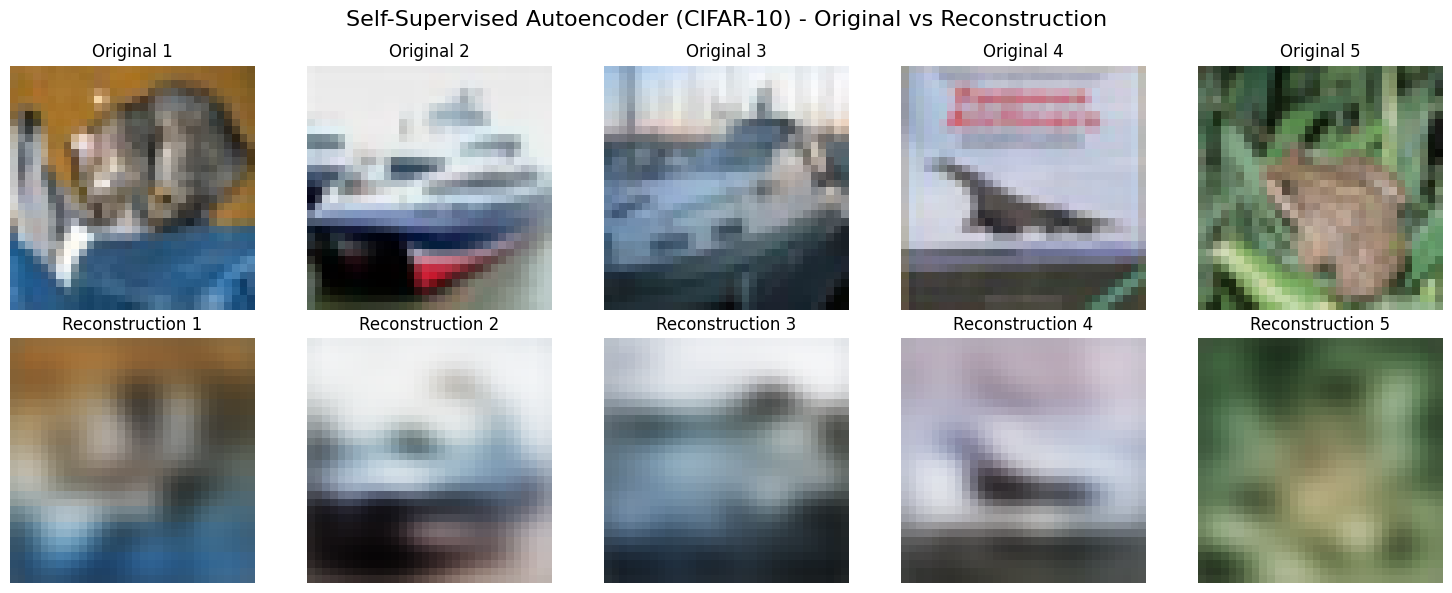

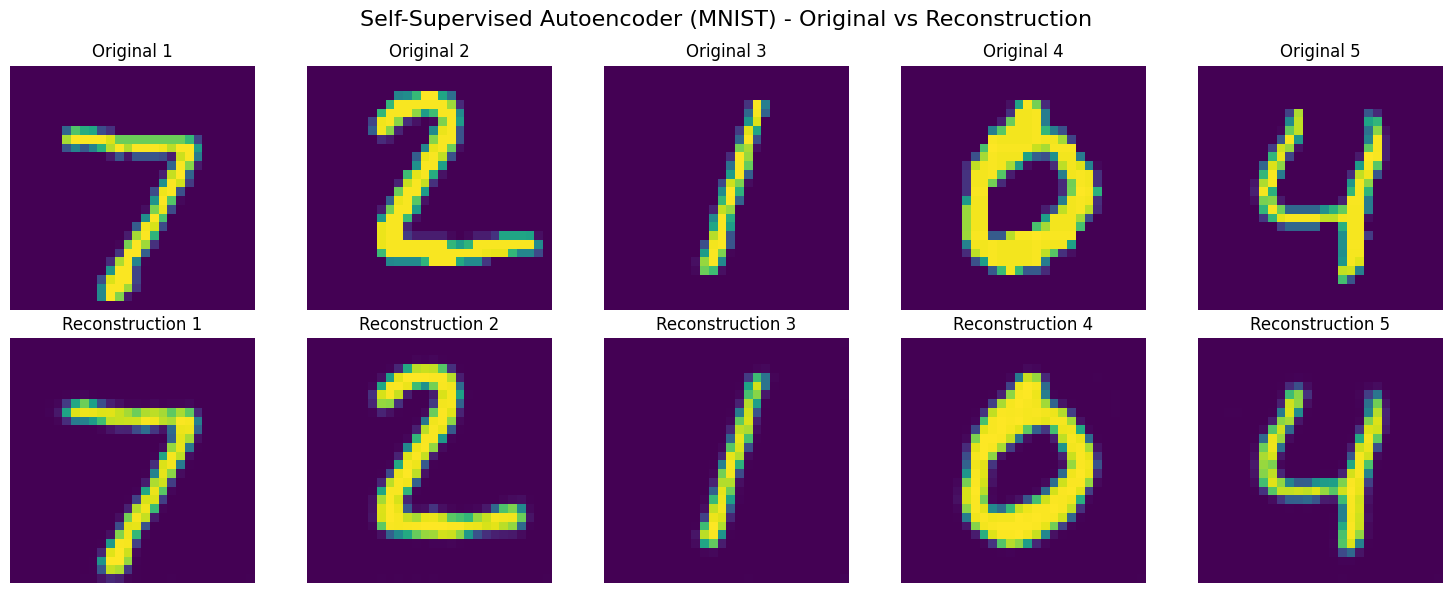

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_reconstructions(autoencoder, dataloader, device, title_prefix=""):
    """
    Plot original images and their reconstructions side by side.
    Args:
        autoencoder: The trained autoencoder model.
        dataloader: DataLoader for the test dataset.
        device: Device to run the model on (e.g., 'cuda' or 'cpu').
        title_prefix: A string to prepend to the plot title for better context.
    """
    autoencoder.eval()
    images, reconstructions = [], []

    # Randomly select 5 images from the test dataset
    with torch.no_grad():
        for data in dataloader:
            inputs, _ = data
            inputs = inputs.to(device)
            outputs = autoencoder(inputs)  # Get reconstructions
            images.append(inputs.cpu())
            reconstructions.append(outputs.cpu())
            if len(images) >= 5:  # Stop after collecting 5 images
                break

    # Convert tensors to numpy arrays
    images = torch.cat(images)[:5].numpy()
    reconstructions = torch.cat(reconstructions)[:5].numpy()

    # Plot original images and their reconstructions
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(5):
        # Original image
        axes[0, i].imshow(np.transpose(images[i], (1, 2, 0)))  # Convert CHW to HWC
        axes[0, i].axis('off')
        axes[0, i].set_title(f"Original {i+1}")

        # Reconstructed image
        axes[1, i].imshow(np.transpose(reconstructions[i], (1, 2, 0)))  # Convert CHW to HWC
        axes[1, i].axis('off')
        axes[1, i].set_title(f"Reconstruction {i+1}")

    fig.suptitle(f"{title_prefix} - Original vs Reconstruction", fontsize=16)
    plt.tight_layout()
    plt.show()


# Plot reconstructions for the first self-supervised autoencoder (CIFAR-10)
plot_reconstructions(
    autoencoder=autoencoder_self_supervised_cifar,
    dataloader=test_loader_self_supervised_cifar,
    device=device,
    title_prefix="Self-Supervised Autoencoder (CIFAR-10)"
)

# Plot reconstructions for the second self-supervised autoencoder (MNIST)
plot_reconstructions(
    autoencoder=autoencoder_self_supervised_mnist,
    dataloader=test_loader_self_supervised_mnist,
    device=device,
    title_prefix="Self-Supervised Autoencoder (MNIST)"
)

# **1.4.4. Linear Interpolation**

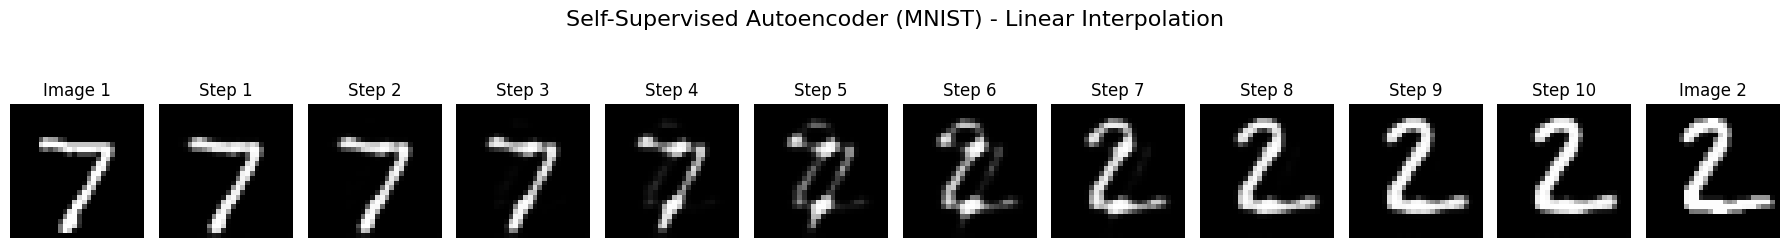

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def linear_interpolation(autoencoder, dataloader, device, title_prefix=""):
    """
    Perform linear interpolation between two images' encodings and visualize the results.
    Args:
        autoencoder: The trained autoencoder model (self-supervised).
        dataloader: DataLoader for the test dataset.
        device: Device to run the model on (e.g., 'cuda' or 'cpu').
        title_prefix: A string to prepend to the plot title for better context.
    """
    autoencoder.eval()

    # Select two random images from the test dataset
    with torch.no_grad():
        for data in dataloader:
            images, _ = data
            images = images.to(device)
            image1, image2 = images[0], images[1]  # Select the first two images
            break

    # Encode the two images to obtain their latent representations
    latent1 = autoencoder.encoder(image1.unsqueeze(0))  # Add batch dimension
    latent2 = autoencoder.encoder(image2.unsqueeze(0))  # Add batch dimension

    # Perform linear interpolation in the latent space
    interpolations = []
    for alpha in np.linspace(0, 1, 10):  # 10 steps
        interpolated_latent = (1 - alpha) * latent1 + alpha * latent2
        interpolations.append(interpolated_latent)

    # Decode the interpolated latent representations
    interpolations = torch.cat(interpolations, dim=0)  # Stack all interpolations
    reconstructions = autoencoder.decoder(interpolations).detach().cpu().numpy()

    # Plot the original images and the interpolations
    fig, axes = plt.subplots(1, 12, figsize=(18, 3))

    # Plot the original images
    axes[0].imshow(image1.cpu().squeeze(), cmap='gray')
    axes[0].axis('off')
    axes[0].set_title("Image 1")

    axes[-1].imshow(image2.cpu().squeeze(), cmap='gray')
    axes[-1].axis('off')
    axes[-1].set_title("Image 2")

    # Plot the interpolations
    for i in range(10):
        axes[i + 1].imshow(reconstructions[i].squeeze(), cmap='gray')
        axes[i + 1].axis('off')
        axes[i + 1].set_title(f"Step {i+1}")

    fig.suptitle(f"{title_prefix} - Linear Interpolation", fontsize=16)
    plt.tight_layout()
    plt.show()

# Perform linear interpolation for the self-supervised autoencoder (MNIST)
linear_interpolation(
    autoencoder=autoencoder_self_supervised_mnist,
    dataloader=test_loader_self_supervised_mnist,
    device=device,
    title_prefix="Self-Supervised Autoencoder (MNIST)"
)


# Interpolation analysis:

The fact that the interpolations look like handwritten digits suggests that:

- The latent space is well-structured and captures the semantic features of the data.
- The decoder is effective at mapping latent representations back to the image domain.
- The model has learned a meaningful representation of the handwritten digit dataset.

This is a positive outcome, as it indicates that our model is working as intended and has successfully learned a smooth and meaningful latent space.

# **1.4.5. TSNE Visualization**


Generating t-SNE plots for Autoencoder 1 (Self-Supervised CIFAR-10)...


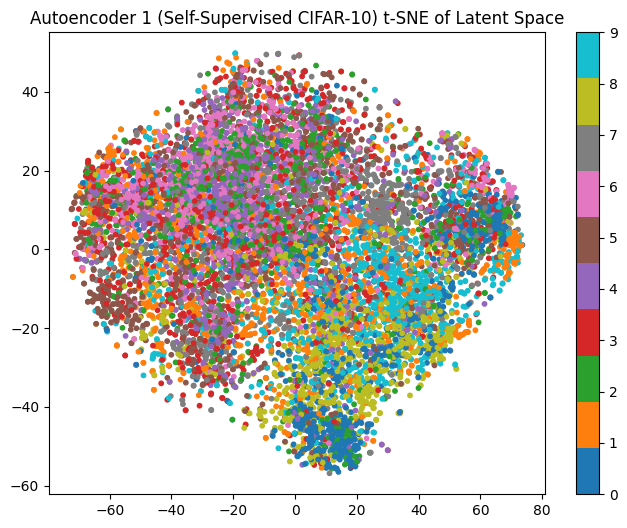

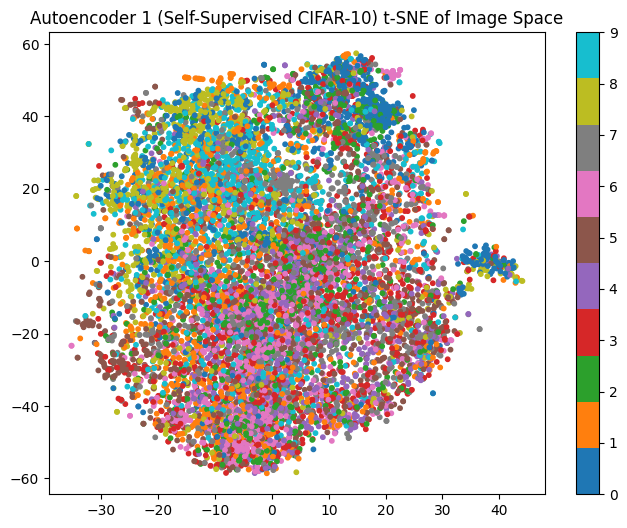

Generating t-SNE plots for Autoencoder 2 (Self-Supervised MNIST)...


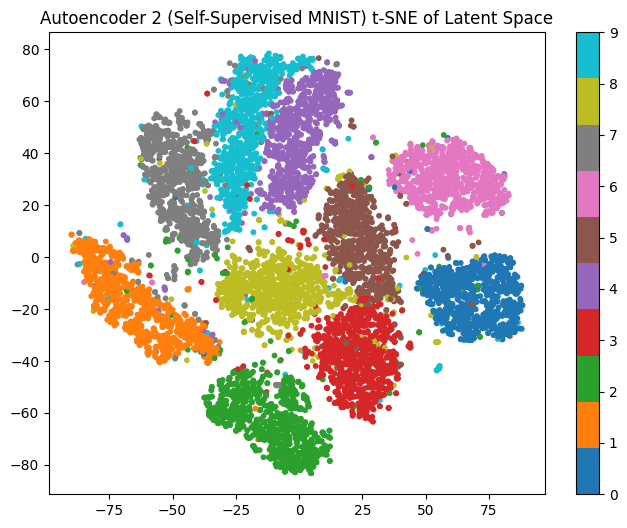

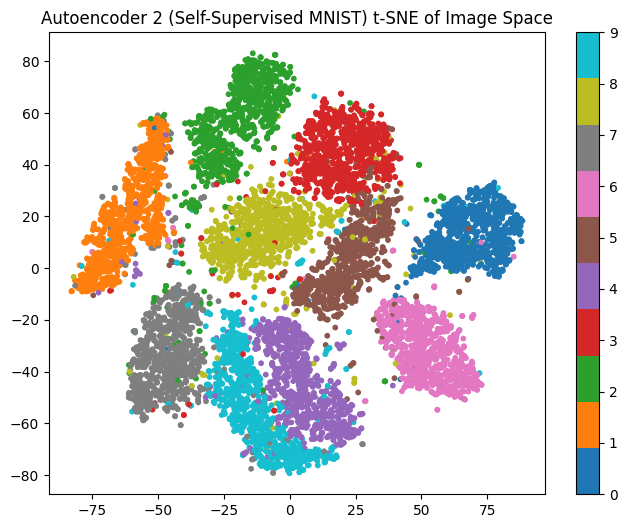

Generating t-SNE plots for Autoencoder 3 (Classification CIFAR-10)...


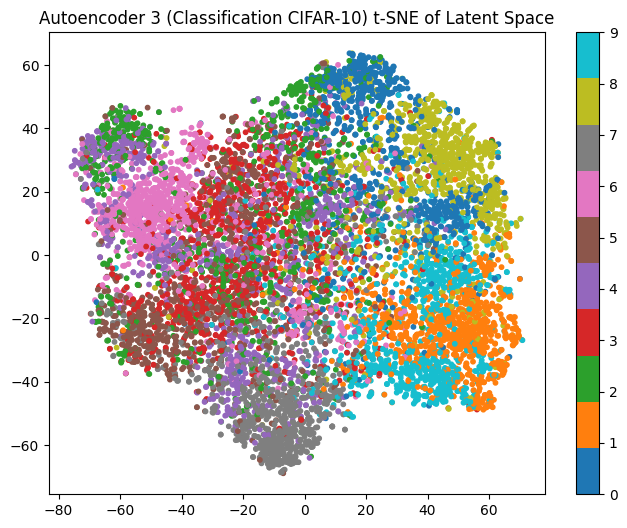

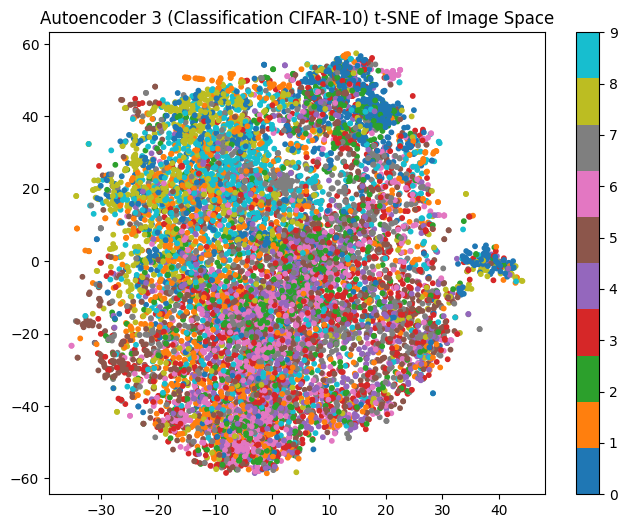

Generating t-SNE plots for Autoencoder 4 (Classification MNIST)...


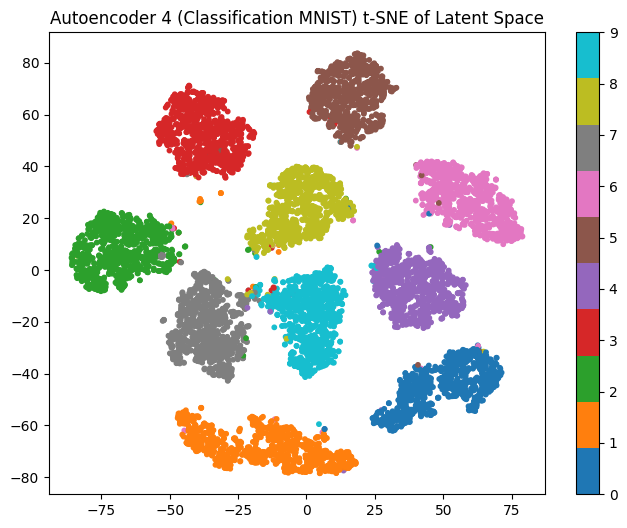

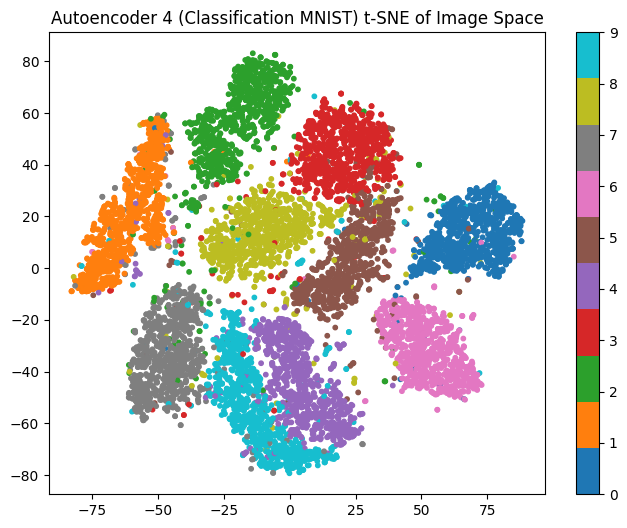

Generating t-SNE plots for Autoencoder 5 (SimCLR CIFAR-10)...


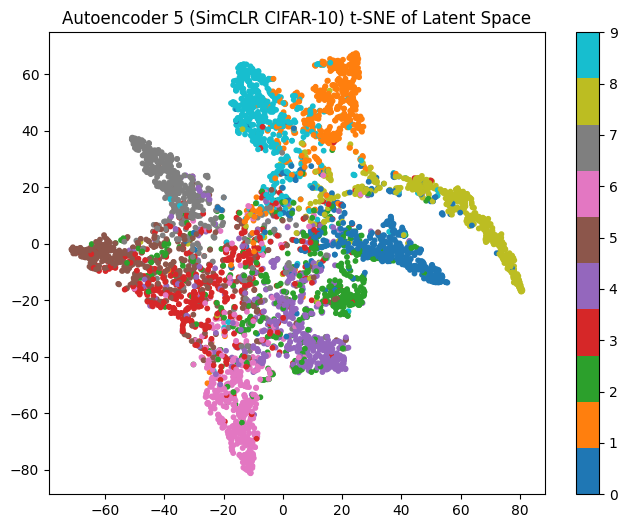

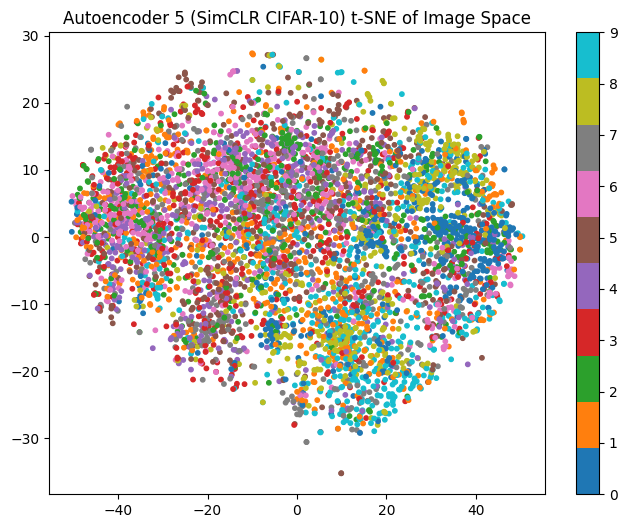

Generating t-SNE plots for Autoencoder 6 (SimCLR MNIST)...


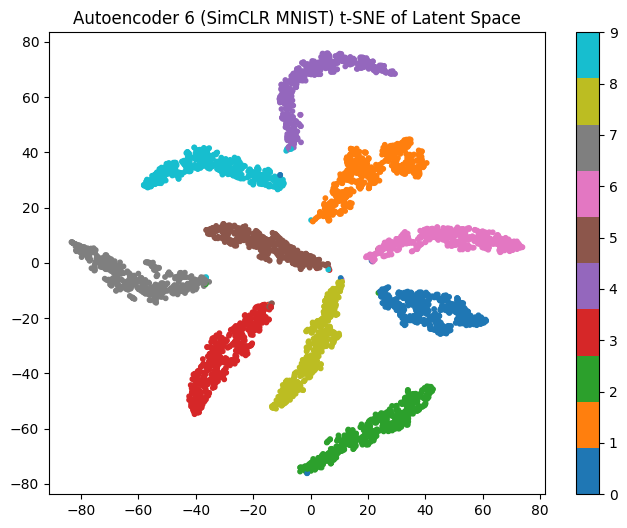

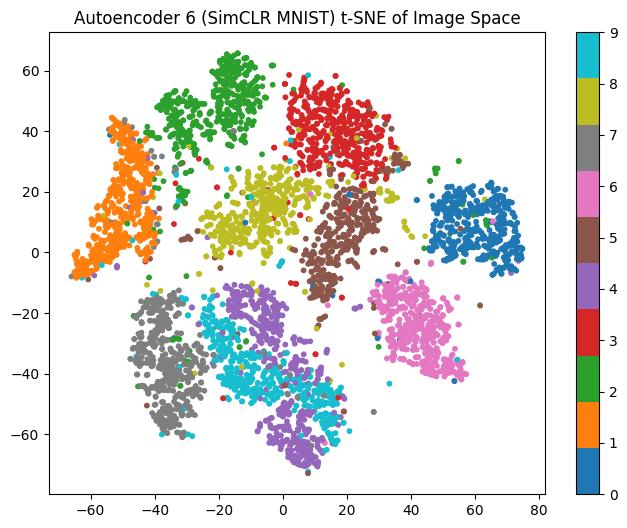

In [11]:
# Visualization for all autoencoders
autoencoders = [
    {"name": "Autoencoder 1 (Self-Supervised CIFAR-10)", "model": autoencoder_self_supervised_cifar, "dataloader": test_loader_self_supervised_cifar},
    {"name": "Autoencoder 2 (Self-Supervised MNIST)", "model": autoencoder_self_supervised_mnist, "dataloader": test_loader_self_supervised_mnist},
    {"name": "Autoencoder 3 (Classification CIFAR-10)", "model": autoencoder_classification_cifar, "dataloader": test_loader_classification_cifar},
    {"name": "Autoencoder 4 (Classification MNIST)", "model": autoencoder_classification_mnist, "dataloader": test_loader_classification_mnist},
    {"name": "Autoencoder 5 (SimCLR CIFAR-10)", "model": simclr_cifar_encoder, "dataloader": test_loader_simclr_cifar},
    {"name": "Autoencoder 6 (SimCLR MNIST)", "model": simclr_mnist_encoder, "dataloader": test_loader_simclr_mnist},
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for autoencoder in autoencoders:
    print(f"Generating t-SNE plots for {autoencoder['name']}...")
    plot_tsne_Title(
        model=autoencoder["model"].encoder,  # Pass the encoder part of the autoencoder
        dataloader=autoencoder["dataloader"],
        device=device,
        title_prefix=autoencoder["name"]
    )

# **T-SNE Projections Analysis**

# Cifar Comparison:

# General Differences Between Latent Spaces

- Self-Supervised Training (1.2.1):

The latent space is more clumped overall, but there is some grouping of similar classes (e.g., colors or textures) in the t-SNE latent representation.
This suggests that self-supervised training captures some meaningful features but lacks the explicit class separation seen in classification-guided training.

- Classification-Guided Training (1.2.2):

The latent space shows slightly better separation compared to self-supervised training.
However, the representations are still clumped, indicating that the model struggles to fully separate classes in the latent space.
This is expected, as classification-guided training explicitly optimizes for class separation but may not generalize well to unseen data.

- SimCLR Latent training (1.2.3):
The SimCLR latent space is significantly better separated compared to both classification-guided and self-supervised training.

The t-SNE plot shows clear grouping of colors (representing classes), with less overlap between clusters.
While there is still some clumping in the center, the overall structure is much more organized, indicating that SimCLR has learned a more meaningful and separable latent space.

Why SimCLR Works Better:

SimCLR uses contrastive learning to explicitly maximize the similarity between positive pairs and minimize the similarity between negative pairs, leading to better feature separation in the latent space.

# Mnist Comparison:

- Self-Supervised Training (1.2.1):

The latent space is well-formed, with clear class separation.
However, there are a minor number of stray points (dots) on the t-SNE plot, where some samples appear in regions belonging to other classes.
This indicates that while the latent space is meaningful, there is room for improvement in separating certain classes.

- Classification-Guided Training (1.2.2):

The latent space shows a slight improvement compared to self-supervised training.
There are fewer stray points, and the class clusters are slightly more compact.
Overall, the latent space is very good, with clear class separation.

- SimCLR Latent Training (1.2.3):

The SimCLR latent space shows an even more slightly improved structure compared to classification-guided training.
The class clusters are well-separated, and there are very few stray points.
All three methods produce good latent spaces, but SimCLR achieves the most refined separation.


# **Differences Between Signal-Domain and Latent Representations**

1. **CIFAR**:

- **Signal-Domain Representations**:
  - The t-SNE plots for the image domain (raw pixel space) are highly unstructured, with no clear grouping of classes.
  - This is expected, as the raw pixel space does not capture semantic relationships between images.

- **Latent Representations**:
  - The latent space is more structured, with some degree of class separation, especially in classification-guided and SimCLR training.
  - This indicates that the learned representations capture higher-level semantic features, making them more useful for downstream tasks.

2. **MNIST**:

- **Self-Supervised Training (1.2.1)**:
  - The image domain is actually similar to the latent domain, with both showing some degree of class grouping.
  - This suggests that even in the raw pixel space, MNIST images have inherent structure due to their simplicity and distinct class features.

- **Classification-Guided Training (1.2.2)**:
  - The latent space is more separable than the image space, with clearer class clusters.
  - However, the image space still shows some grouping of classes, reflecting the simplicity of MNIST and the inherent separability of its digits.

- **SimCLR Latent Training (1.2.3)**:
  - The latent space is very clearly separable, with distinct and compact clusters for each class.
  - The image space is also separable but shows some overlap in certain regions, where colors (representing classes) are not perfectly grouped. This indicates that while the latent space benefits from contrastive learning, the raw pixel space still has limitations in capturing semantic relationships.